In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from data.charge.synthetic_sim import ChargedParticlesSim
from torchsummary import summary

In [2]:
os.cpu_count()

128

In [13]:
n_balls = 10
_charge_types = np.array([-1., 0., 1.])
charge_prob=[1. / 2, 0, 1. / 2]

charges = np.random.choice(_charge_types, size=(n_balls, 1), p=charge_prob)
charges, charges.shape

(array([[-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.],
        [ 1.],
        [-1.],
        [-1.],
        [ 1.],
        [-1.]]),
 (10, 1))

In [5]:
arr = torch.tensor([1,2,3])==0

In [14]:
charges.dot(charges.transpose())
# if same charge 1 else -1

array([[ 1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.],
       [-1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.],
       [-1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.],
       [-1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.],
       [ 1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.],
       [-1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.],
       [ 1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.],
       [ 1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.],
       [-1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1., -1.],
       [ 1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.]])

In [15]:
!python data/charge_simulation/synthetic_sim.py

python: can't open file '/home/ommprakash.sahoo/agent/data/charge_simulation/synthetic_sim.py': [Errno 2] No such file or directory


/home/ommprakash.sahoo/agent/data/charge/synthetic_sim.py:97: RuntimeWarning: invalid value encountered in power
  l2_dist_power3 = np.power(
/home/ommprakash.sahoo/agent/data/charge/synthetic_sim.py:126: RuntimeWarning: invalid value encountered in power
  l2_dist_power3 = np.power(


[[ 1.]
 [ 1.]
 [ 1.]
 [-1.]
 [-1.]]
Simulation time: 0.5888395309448242


IndexError: index 1 is out of bounds for axis 1 with size 1

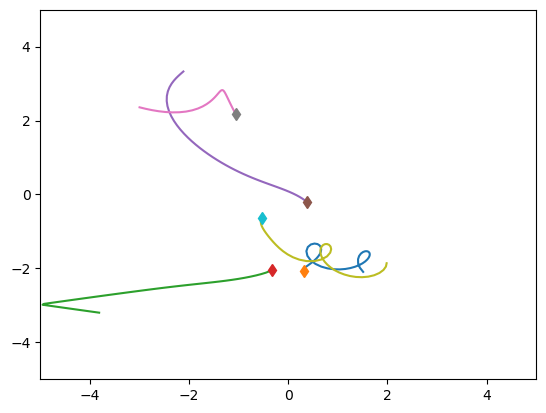

<Figure size 640x480 with 0 Axes>

In [2]:
sim = ChargedParticlesSim()
t = time.time()
loc, vel, edges = sim.sample_trajectory(T=5000, sample_freq=100)

print(edges)
print("Simulation time: {}".format(time.time() - t))
vel_norm = np.sqrt((vel ** 2).sum(axis=1))
plt.figure()
axes = plt.gca()
axes.set_xlim([-5., 5.])
axes.set_ylim([-5., 5.])
for i in range(loc.shape[-1]):
    plt.plot(loc[:, 0, i], loc[:, 1, i])
    plt.plot(loc[0, 0, i], loc[0, 1, i], 'd')
plt.figure()
energies = [sim._energy(loc[i, :, :], vel[i, :, :], edges) for i in
            range(loc.shape[0])]
plt.plot(energies)
plt.show()

In [ ]:
# train_charge = torch.randn(10, 5, 1, dtype=int)
charge_numpy = np.random.randint(0, 3, size=(1, 5), dtype=np.int64)  # Ensure the NumPy array is of integer type
charge = torch.from_numpy(charge_numpy)
train_location = torch.randn(10000, 99, 2, 5)
train_velocity = torch.randn(10000, 99, 2, 5)

In [ ]:
train_location = train_location.transpose(-1, -2)
train_location.shape

torch.Size([10000, 99, 5, 2])

In [ ]:
charge

tensor([[1, 1, 2, 2, 2]])

In [ ]:
charge_expanded = charge.unsqueeze(1)  # shape: (sample, 1, n, 1)

# Repeat the tensor along the second dimension
charge_repeated = charge_expanded.repeat(1, 2, 1)

In [ ]:
charge_repeated

tensor([[[1, 1, 2, 2, 2],
         [1, 1, 2, 2, 2]]])

In [ ]:
charge_repeated.shape

torch.Size([1, 2, 5])

In [ ]:
path = 'data/charge_simulation/charged5'

files = os.listdir(path)

for file in files:
    arr = np.load(os.path.join(path, file))
    print(file, '\t',arr.shape)

del arr

loc_train_charged5.npy 	 (50000, 49, 2, 5)
vel_train_charged5.npy 	 (50000, 49, 2, 5)
charges_train_charged5.npy 	 (50000, 5, 1)
loc_valid_charged5.npy 	 (10000, 49, 2, 5)
vel_valid_charged5.npy 	 (10000, 49, 2, 5)
charges_valid_charged5.npy 	 (10000, 5, 1)
loc_test_charged5.npy 	 (10000, 99, 2, 5)
vel_test_charged5.npy 	 (10000, 99, 2, 5)
charges_test_charged5.npy 	 (10000, 5, 1)


In [ ]:
import yaml
from types import SimpleNamespace

def dict_to_namespace(config_dict):
    if isinstance(config_dict, dict):
        return SimpleNamespace(**{k: dict_to_namespace(v) for k, v in config_dict.items()})
    elif isinstance(config_dict, list):
        return [dict_to_namespace(i) for i in config_dict]
    else:
        return config_dict

def load_config(file_path):
    with open(file_path, 'r') as stream:
        try:
            config_data = yaml.safe_load(stream)
            return dict_to_namespace(config_data)
        except yaml.YAMLError as exc:
            print(f"Error loading YAML file: {exc}")
            return None

In [ ]:
config = load_config('config.yml')

In [ ]:
emb = nn.Embedding(5, 8)

arr = np.random.randint(1)

In [ ]:
arr

0

In [ ]:
emb(torch.arange(0,5,dtype=int)).shape

torch.Size([5, 8])

In [ ]:
torch.tensor(np.arange(5, dtype=int)).shape

torch.Size([5])

In [ ]:
torch.randperm(5)

tensor([0, 3, 4, 2, 1])

In [ ]:
sz=15
mask = torch.triu(torch.ones(sz,sz), diagonal=1)
# mask.masked_fill_(mask==1, float('inf'))
mask

tensor([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0.,

In [ ]:
def mask(time, agent):
        sz = time*agent
        mask = torch.zeros(sz, sz)
        for step in range(time):
            start = agent * step
            stop = start + agent
            # The players can look at the other players.
            mask[start:stop, :stop] = 1

        # mask = mask.masked_fill(mask == 0, float("-inf"))
        # mask = mask.masked_fill(mask == 1, float(0.0))
        return mask

In [ ]:
mask(5,3)

tensor([[1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1.,

In [ ]:
seq_len = 5
subsequent_mask = (torch.triu(torch.ones(seq_len, seq_len)) == 1).transpose(0, 1)

# subsequent_mask = subsequent_mask.float().masked_fill(subsequent_mask == 0, float('-inf')).masked_fill(subsequent_mask == 1, float(0.0))
subsequent_mask==0

tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])

In [ ]:
s2 = 3
s1 = 7
agent = 1
mask = torch.zeros(s2*agent, s1*agent)
lookup = s1-s2
j = 0
for i in range(s2):
        rstart, rend = i*agent, (i+1)*agent
        cstart, cend = j*agent, (j+lookup)*agent
        mask[rstart:rend, cstart:cend] = 1
        j+=1
# mask = mask.masked_fill(mask == 0, True)
# mask = mask.masked_fill(mask == 1, False)

mask==0

tensor([[False, False, False, False,  True,  True,  True],
        [ True, False, False, False, False,  True,  True],
        [ True,  True, False, False, False, False,  True]])

In [ ]:
mask

tensor([[1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 0., 0., 0., 0.],
        [0., 0., 1., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.]])

In [ ]:
sz=6
mask = torch.triu(torch.ones(sz,sz), diagonal=1)
mask==1

tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])

In [ ]:
time, agent = 5,2
sz = time*agent
mask = torch.zeros(sz, sz)
for step in range(time):
        start = agent * step
        stop = start + agent
        # The players can look at the other players.
        mask[start:stop, :stop] = 1
mask==0

tensor([[False, False,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False, False],
        [False, False, False, False, False, False, False, False, False, False]])

In [ ]:
n_encoder_seq, n_decoder_seq = 4,2
n_particles=1
assert n_encoder_seq>n_decoder_seq, "The seq length for the encoder should be larger than decoder seq."
mask = torch.zeros(n_decoder_seq*n_particles, n_encoder_seq*n_particles)
lookup = n_encoder_seq-n_decoder_seq
j = 0
for i in range(n_decoder_seq):
        rstart, rend = i*n_particles, (i+1)*n_particles
        cstart, cend = j*n_particles, (j+lookup)*n_particles
        mask[rstart:rend, cstart:cend] = 1
        j+=1
arr = mask==0

In [ ]:
import torch

# Example velocity data (replace with your actual data)
velocity_ = torch.randn(10, 20, 5, 2)  # Shape: (sample, time, n_particles, 2)

# Reshape to (sample * time * n_particles, 2)
velocity_reshaped = velocity_.view(-1, 2)

# Compute min and max along each component (column)
min_vals = velocity_reshaped.min(dim=0)[0]
max_vals = velocity_reshaped.max(dim=0)[0]

# Define custom min and max values for scaling
custom_min = torch.tensor([-5.0, -10.0])  # Example custom min values
custom_max = torch.tensor([5.0, 10.0])    # Example custom max values

# Perform min-max scaling manually
scaled_velocity_reshaped = custom_min + (velocity_reshaped - min_vals) * (custom_max - custom_min) / (max_vals - min_vals)

# Reshape back to original shape
scaled_velocity = scaled_velocity_reshaped.view(velocity_.size())

# # Print scaled data and verify range
# print("Original velocity_ tensor:")
# print(velocity_)
# print("\nScaled velocity_ tensor:")
# print(scaled_velocity)
# print("\nMin values after scaling:")
# print(scaled_velocity.min(dim=-2)[0])
# print("\nMax values after scaling:")
# print(scaled_velocity.max(dim=-2)[0])

Original velocity_ tensor:
tensor([[[[ 5.3130e-01,  6.0411e-01],
          [-4.6917e-01, -1.6680e-01],
          [-7.6530e-01, -9.6994e-01],
          [-1.2359e+00,  7.0655e-01],
          [-8.1759e-01,  6.2558e-01]],

         [[ 2.3495e+00,  1.9899e+00],
          [ 6.1284e-02,  1.7187e+00],
          [-1.9663e-01,  7.9733e-01],
          [-4.0361e-01, -4.1996e-01],
          [-1.9795e-01,  8.0108e-02]],

         [[-2.4754e-01,  1.0046e-01],
          [-5.3842e-01, -3.5854e-02],
          [ 1.5272e+00,  4.9672e-01],
          [-1.3363e+00, -4.8637e-01],
          [ 7.7401e-02, -1.2446e+00]],

         ...,

         [[ 6.6565e-01, -2.2985e-01],
          [-3.2706e-02,  9.5576e-01],
          [-3.5596e-01, -5.6032e-01],
          [ 1.8259e+00,  2.3098e+00],
          [ 1.1704e+00, -1.1015e-01]],

         [[-6.0010e-01, -1.5600e-01],
          [-7.9092e-01, -2.0330e-02],
          [ 6.7585e-01,  1.1119e+00],
          [-1.2715e+00,  1.0496e+00],
          [ 7.0856e-01,  5.0710e-01]],

In [ ]:
velocity_reshaped.min(dim=0)

torch.return_types.min(
values=tensor([-3.4766, -3.4434]),
indices=tensor([546, 989]))

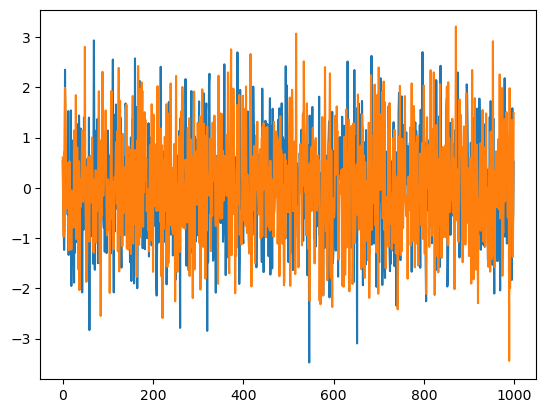

In [ ]:
plt.plot(velocity_reshaped)

In [3]:
from torch.utils.data import Dataset

class ChargedParticleData(Dataset):
    def __init__(self, mode, directory, n_particles, name_format) -> None:
        super().__init__()
        self.mode = mode
        self.directory = directory
        self.n_particles = n_particles
        self.name_format = name_format

        (self.charge, self.location, self.velocity) = self.load_data()
        self.dataset = self.transform_data(self.charge, self.location, self.velocity) # shape: (sample, time, n_particles, 5)

    def load_data(self): 
        charge = np.load(os.path.join(self.directory, self.name_format.format(data='charges', mode=self.mode, n=self.n_particles))) # shape: (sample, n_particles, 1)
        location = np.load(os.path.join(self.directory, self.name_format.format(data='loc', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)
        velocity = np.load(os.path.join(self.directory, self.name_format.format(data='vel', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)

        charge = torch.from_numpy(charge) # shape: (sample, n_particles, 1)
        location = torch.from_numpy(location) # shape: (sample, time, 2, n_particles)
        velocity = torch.from_numpy(velocity) # shape: (sample, time, 2, n_particles)
        return charge, location, velocity

    def transform_data(self, charge, location, velocity):
        time = velocity.size(1)
        location_ = location.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        ans = torch.max(location_, dim=-1, keepdim=True)
        # print(ans.size())
        velocity_ = velocity.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        charge_ = charge.unsqueeze(1).repeat(1,time,1,1) # shape: (sample, time, n_particles, 1)
        data = torch.concat([charge_, location_, velocity_], dim=-1) # shape: (sample, time, n_particles, 5)
        self.n_features = data.size(-1)
        self.n_particles = data.size(-2)
        return data # shape: (sample, time, n_particles, 5)

    def __len__(self):
        return self.dataset.size(0)
    
    def __getitem__(self, index):
        # print('Inside dataloader', self.dataset[index].size())
        return {
            'data': self.dataset[index], # shape: (1, time, n_particles, 5)
            'location': self.location[index], # shape: (1, time, 2, n_particles)
            'velocity': self.velocity[index], # shape: (1, time, 2, n_particles)
            'charge': self.charge[index] # shape: (1, n_particles, 1)
        }    


In [4]:
# from data.charge.charge_dataset import ChargedParticleData
directory = os.path.join('data', 'charge', f'charged{5}')
valid_data = ChargedParticleData('valid', directory, 5, '{data}_{mode}_charged{n}.npy')

In [7]:
charge, location, velocity = valid_data.load_data()

In [5]:
charge.size(), location.size(), velocity.size()

(torch.Size([10000, 5, 1]),
 torch.Size([10000, 49, 2, 5]),
 torch.Size([10000, 49, 2, 5]))

In [8]:
samples = charge.size(0)
n = np.random.randint(0, samples)
def random_sample(n):
        c,l,v = charge[n], location[n], velocity[n]
        l = l.transpose(-1, -2)
        v = v.transpose(-1, -2)
        return c,l,v


In [55]:
c.shape, l.shape, v.shape

(torch.Size([5, 1]), torch.Size([49, 5, 2]), torch.Size([49, 5, 2]))

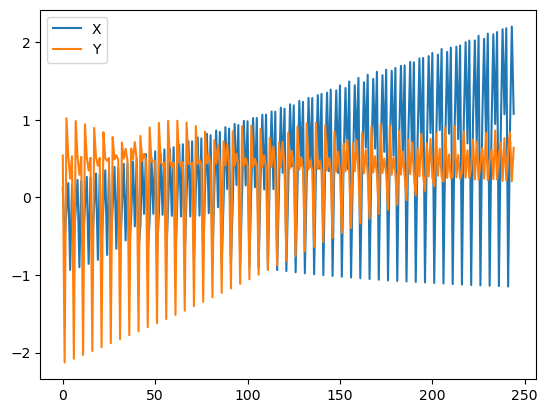

In [7]:
c,l,v = random_sample(np.random.randint(0, samples))
plt.plot(l.reshape(-1, 2), label = ['X','Y'])
# plt.plot(l.reshape(-1, 2).mean())
plt.legend()
plt.show()

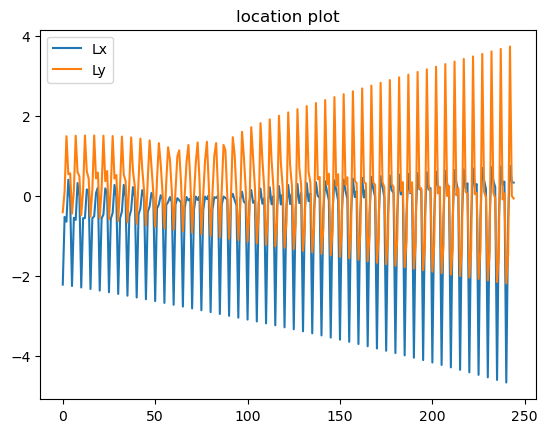

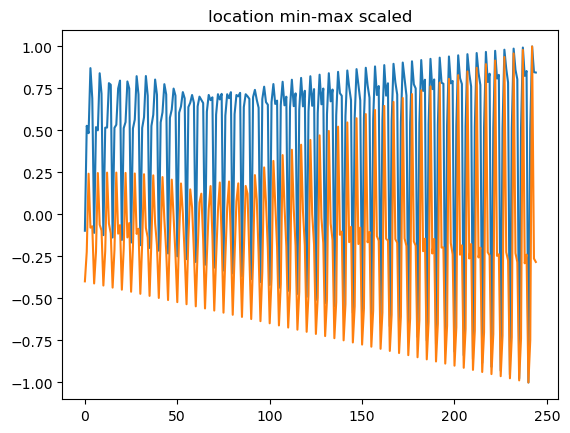

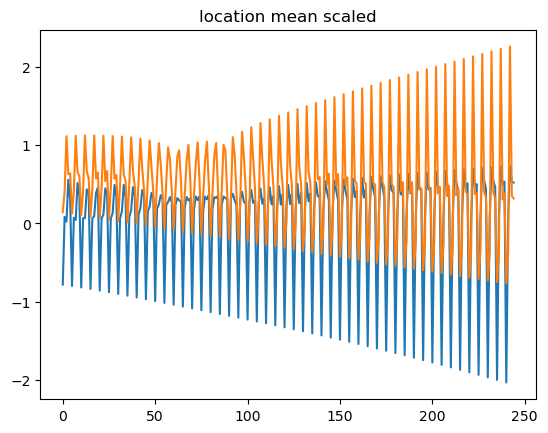

In [9]:
c,l,v = random_sample(np.random.randint(0, samples))
plt.plot(l.reshape(-1, 2), label = ['Lx','Ly'])
plt.legend()
plt.title('location plot')
plt.show()

minl = l.reshape(-1, 2).min(dim=0)
maxl = l.reshape(-1, 2).max(dim=0)
meanl = l.reshape(-1, 2).mean(dim=0)
stdl = l.reshape(-1, 2).std(dim=0)
ans = 2*(l.reshape(-1, 2)-minl[0])/(maxl[0]-minl[0])-1

plt.plot(ans, label = ['Lx','Ly'])
plt.title('location min-max scaled')
plt.show()

ans = (l.reshape(-1, 2)-meanl[0])/stdl[0]**2

plt.plot(ans, label = ['Lx','Ly'])
plt.title('location mean scaled')
plt.show()

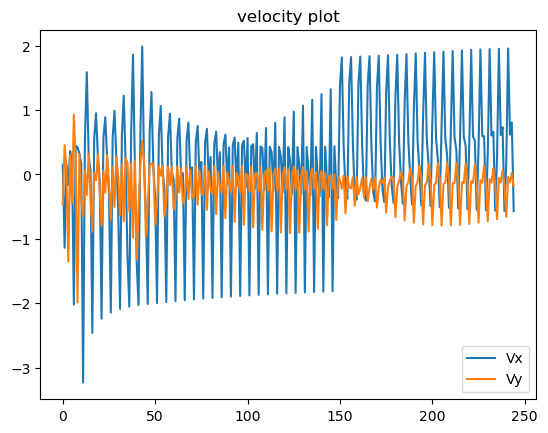

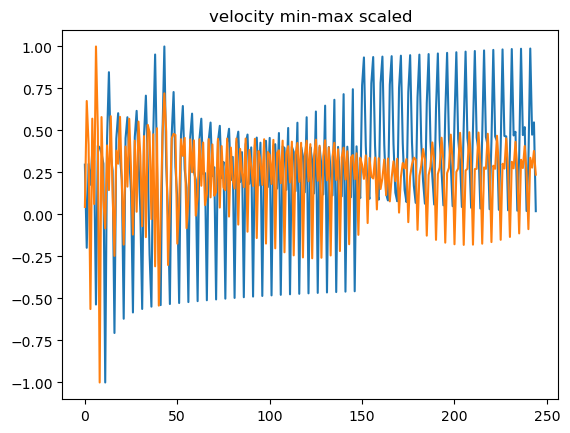

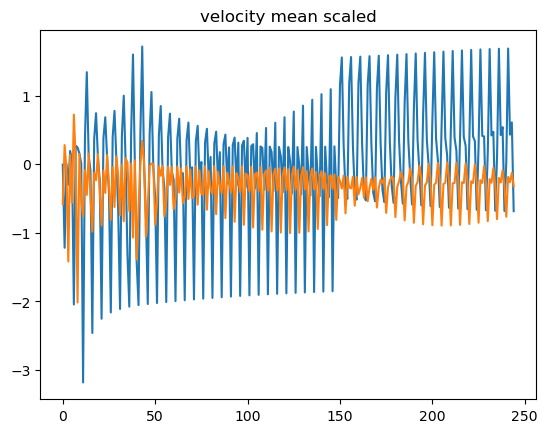

In [22]:
c,l,v = random_sample(np.random.randint(0, samples))
# v = c
plt.plot(v.reshape(-1, 2), label = ['Vx','Vy'])
plt.legend()
plt.title('velocity plot')
plt.show()

minv = v.reshape(-1, 2).min(dim=0)
maxv = v.reshape(-1, 2).max(dim=0)
meanv = v.reshape(-1, 2).mean(dim=0)
stdv = v.reshape(-1, 2).std(dim=0)
ans = 2*(v.reshape(-1, 2)-minv[0])/(maxv[0]-minv[0])-1

plt.plot(ans, label = ['Vx','Vy'])
plt.title('velocity min-max scaled')
plt.show()

ans = (v.reshape(-1, 2)-meanv[0])/stdv[0]**2

plt.plot(ans, label = ['Vx','Vy'])
plt.title('velocity mean scaled')
plt.show()

In [41]:
c,l,v = random_sample(np.random.randint(0, samples))
2*(c-1)/(2)+1==c

tensor([[True],
        [True],
        [True],
        [True],
        [True]])

In [104]:
ans = (v.reshape(-1, 2)-minv[0])/(maxv[0]-minv[0])

In [108]:
ans.shape, v.reshape(-1, 2).shape

(torch.Size([245, 2]), torch.Size([245, 2]))

In [59]:
class ChargedParticleData(Dataset):
    def __init__(self, mode, directory, n_particles, name_format, scale_data=True) -> None:
        super().__init__()
        self.mode = mode
        self.directory = directory
        self.n_particles = n_particles
        self.name_format = name_format
        self.scale_data = scale_data

        (self.charge, self.location, self.velocity) = self.load_data()
        self.dataset = self.transform_data(self.charge, self.location, self.velocity) # shape: (sample, time, n_particles, 5)

    def load_data(self): 
        charge = np.load(os.path.join(self.directory, self.name_format.format(data='charges', mode=self.mode, n=self.n_particles))) # shape: (sample, n_particles, 1)
        location = np.load(os.path.join(self.directory, self.name_format.format(data='loc', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)
        velocity = np.load(os.path.join(self.directory, self.name_format.format(data='vel', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)

        charge = torch.from_numpy(charge) # shape: (sample, n_particles, 1)
        location = torch.from_numpy(location) # shape: (sample, time, 2, n_particles)
        velocity = torch.from_numpy(velocity) # shape: (sample, time, 2, n_particles)
        return charge, location, velocity

    def transform_data(self, charge, location, velocity):
        time = velocity.size(1)
        location_ = location.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        velocity_ = velocity.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        charge_ = charge.unsqueeze(1).repeat(1,time,1,1) # shape: (sample, time, n_particles, 1)
        
        data = torch.concat([charge_, location_, velocity_], dim=-1) # shape: (sample, time, n_particles, 5)
        self.n_features = data.size(-1)
        self.n_particles = data.size(-2)
        return data # shape: (sample, time, n_particles, 5)

    def __len__(self):
        return self.dataset.size(0)
    
    def __getitem__(self, index, custom_range=True):
        data = self.dataset[index] # shape: (1, time, n_particles, 5)
        if self.scale_data:
            data_ = data.reshape(-1, data.size(-1))
            if custom_range:
                min_ = torch.tensor([1, -5, -5, -7, -7])
                max_ = torch.tensor([0, 5, 5, 7, 7])
            else:
                min_ = data_.min(dim=0)[0]
                max_ = data_.max(dim=0)[0]
                # print('Velocity Max:', max_[-2:])
            data_ = 2*(data_-min_)/(max_-min_)-1
            # print(data_.size(), data.size())
            data_ = data_.view(data.size())
            data_[:, :, 0] = data[:, :, 0]
        # data = data_
        if torch.isnan(data_).any():
            print('nan value found in', index)
        return {
            'data': data_, # shape: (1, time, n_particles, 5)
            # 'location': self.location[index], # shape: (1, time, 2, n_particles)
            # 'velocity': self.velocity[index], # shape: (1, time, 2, n_particles)
            # 'charge': self.charge[index] # shape: (1, n_particles, 1)
        }    


In [67]:
directory = os.path.join('data', 'charge', f'charged{5}')
train_data = ChargedParticleData('train', directory, 5, '{data}_{mode}_charged{n}.npy')
valid_data = ChargedParticleData('valid', directory, 5, '{data}_{mode}_charged{n}.npy')
test_data = ChargedParticleData('test', directory, 5, '{data}_{mode}_charged{n}.npy')

In [46]:
train_data.dataset.size()

torch.Size([50000, 49, 5, 5])

In [57]:
# charge, X, Y, Vx, Vy
print('Data Sequesnce: charge, X, Y, Vx, Vy')
print('Train Data')
print('Max:',torch.max(train_data.dataset.reshape(-1,5), dim=0)[0])
print('Min:',torch.min(train_data.dataset.reshape(-1,5), dim=0)[0])

print('Valid Data')
print('Max:',torch.max(valid_data.dataset.reshape(-1,5), dim=0)[0])
print('Min:',torch.min(valid_data.dataset.reshape(-1,5), dim=0)[0])

print('Test Data')
print('Max:',torch.max(test_data.dataset.reshape(-1,5), dim=0)[0])
print('Min:',torch.min(test_data.dataset.reshape(-1,5), dim=0)[0])

Data Sequesnce: charge, X, Y, Vx, Vy
Train Data
Max: tensor([1.0000, 5.0000, 5.0000, 6.4477, 5.9122], dtype=torch.float64)
Min: tensor([-1.0000, -5.0000, -5.0000, -6.4701, -6.1946], dtype=torch.float64)
Valid Data
Max: tensor([1.0000, 5.0000, 5.0000, 5.9026, 5.9866], dtype=torch.float64)
Min: tensor([-1.0000, -5.0000, -5.0000, -5.8401, -6.1741], dtype=torch.float64)
Test Data
Max: tensor([1.0000, 5.0000, 5.0000, 5.8954, 5.9297], dtype=torch.float64)
Min: tensor([-1.0000, -5.0000, -5.0000, -6.1492, -6.7774], dtype=torch.float64)


In [68]:
data = train_data.__getitem__(100)['data']

In [29]:
data.size()

torch.Size([49, 5, 5])

In [62]:
data[0]

tensor([[-1.0000,  0.0386, -0.4744, -0.0417, -0.0569],
        [-1.0000,  0.3246,  0.0383, -0.0890, -0.0121],
        [-1.0000, -0.3187, -0.0913,  0.0586, -0.0404],
        [ 1.0000,  0.0043,  0.1068, -0.0781,  0.0371],
        [ 1.0000,  0.1769,  0.1045,  0.1060,  0.0117]], dtype=torch.float64)

In [80]:
data = train_data.dataset[7]
torch.isnan(data).any()


tensor(False)

In [97]:
data = train_data.dataset[16]
data_ = data.reshape(-1, data.size(-1))
print(torch.isnan(data_).any())
min_ = data_.min(dim=0)
max_ = data_.max(dim=0)
print(torch.isnan(min_[0]).any(), torch.isnan(max_[0]).any())
data1 = 2*(data_-min_[0])/(max_[0]-min_[0])-1
data1 = data1.view(data.size())
data1 = 
print((data_-min_[0]), (max_[0]-min_[0]))
print(torch.isnan(data_-min_[0]).any(), torch.isnan(data_+min_[0]).any(), torch.isnan(data1).any())
# print(data_.size(), data.size())


tensor(False)
tensor(False) tensor(False)
tensor([[0.0000, 4.0799, 5.6385, 1.1029, 0.9203],
        [0.0000, 2.5681, 4.5088, 1.8653, 1.3019],
        [0.0000, 5.2464, 5.1946, 1.0770, 1.4183],
        ...,
        [0.0000, 7.0114, 8.8481, 2.0914, 2.2349],
        [0.0000, 9.0463, 3.8197, 0.2254, 1.0394],
        [0.0000, 4.9580, 0.0000, 1.8235, 0.0000]], dtype=torch.float64) tensor([0.0000, 9.9427, 9.4644, 2.9613, 2.4455], dtype=torch.float64)
tensor(False) tensor(False) tensor(True)


In [85]:
data_

tensor([[ 1.0000, -0.2588,  0.0747,  0.5227,  0.2476],
        [ 1.0000,  0.4192,  2.0037,  0.1463, -0.4208],
        [ 1.0000, -0.0087, -1.6737,  0.2741, -0.5304],
        ...,
        [ 1.0000,  1.4817, -2.1921,  0.2398,  1.2927],
        [ 1.0000, -1.8963, -1.0456,  1.5051, -0.1723],
        [ 1.0000,  4.9593, -3.0090, -1.2280, -0.7562]], dtype=torch.float64)

In [86]:
min_[0]

tensor([ 1.0000, -4.9727, -4.9797, -1.7030, -1.5014], dtype=torch.float64)

In [88]:
# data_-min_[0]
torch.isnan(data_-min_[0]).any()

tensor(False)

In [65]:
data.size()

torch.Size([50000, 49, 5, 5])

In [ ]:
data_ = data.reshape(-1, data.size(-1))
min_ = data_.min(dim=0)
max_ = data_.max(dim=0)
data_ = 2*(data_-min_[0])/(max_[0]-min_[0])-1
# print(data_.size(), data.size())
data = data_.view(data.size())

In [66]:
type(train_data)

__main__.ChargedParticleData

In [102]:
for dt in train_data:
        if torch.isnan(dt['data']).any():
                print(dt['data'].size(), torch.isnan(dt['data']).sum().item())

In [53]:
if torch.isnan(data).any():
    print("NaN detected in data")

In [33]:
torch.manual_seed(10)

def random_func(arr):
        arr = arr**2
        arr = arr+1
        return arr
arr = torch.randint(1, 10, [10, 20, 5, 4])

temp = arr.reshape(-1, 4) #.clone()
temp = random_func(temp)

# arr == temp.reshape(arr.size())
# check if there any False in the tensor
torch.any(~(random_func(arr)==temp.reshape(arr.size())))

tensor(False)

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

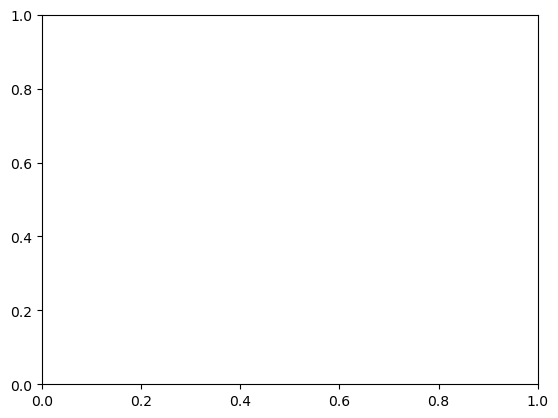

In [2]:
plt.plot(range(10), np.random.randint(10))

In [3]:
np.random.r

TypeError: 'module' object is not callable

In [14]:
from utils import *
config = load_config('config.yml')
train_opt = config.train
model_opt = vars(config.model).get('transformer')
data_opt = vars(config.data).get('charge')
# from train import test_step
from model import Encoder
from utils import *
name = 'charge'
name_format = '{data}_{mode}_charged{n}.npy'
n_particles = 5
encoder_ratio = 0.6
only_encoder = True
n_features = 5 #test_data.dataset.size(-1)

model = Encoder(model_opt, n_features, n_particles)
import io
from contextlib import redirect_stdout

In [15]:
# batch, time, n_particles, d_model
with io.StringIO() as buf, redirect_stdout(buf):
    summary(model, input_size=(5, 512, 512))
    model_summary = buf.getvalue()

In [16]:
print()

'======================================================================\nLayer (type:depth-idx)                        Param #\n======================================================================\n├─ReLU: 1-1                                   --\n├─Embedding: 1-2                              100\n├─Sequential: 1-3                             --\n|    └─Linear: 2-1                            72\n|    └─ReLU: 2-2                              --\n|    └─Dropout: 2-3                           --\n├─TransformerEncoder: 1-4                     --\n|    └─ModuleList: 2-4                        --\n|    |    └─TransformerEncoderLayer: 3-1      8,544\n|    |    └─TransformerEncoderLayer: 3-2      8,544\n├─Sequential: 1-5                             --\n|    └─Linear: 2-5                            1,056\n|    └─ReLU: 2-6                              --\n|    └─Dropout: 2-7                           --\n|    └─Linear: 2-8                            132\n=======================================